In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-06-30"

In [3]:
tsla_df = yf.download("TSLA", start=start_date, end=end_date)

bnd_df = yf.download("BND", start=start_date, end=end_date)

spy_df = yf.download("SPY", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [4]:
tsla_df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


In [5]:
tsla_df.tail()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2026-06-23,381.609985,392.869995,379.059998,392.609985,50420200
2026-06-24,375.529999,384.579987,373.049988,380.079987,37081400
2026-06-25,375.119995,379.119995,371.220001,375.269989,30138800
2026-06-26,379.709991,387.799988,368.600006,370.149994,53434100
2026-06-29,411.839996,413.269989,379.299988,381.790009,57645800


In [11]:
tsla_df.shape


(2888, 5)

In [12]:
tsla_df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[s]', name='Date', length=2888, freq=None)

In [10]:
tsla_df.columns

MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])

In [ ]:
tsla_df.info()
#tells structure of the dataframe

<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2888 non-null   float64
 1   (High, TSLA)    2888 non-null   float64
 2   (Low, TSLA)     2888 non-null   float64
 3   (Open, TSLA)    2888 non-null   float64
 4   (Volume, TSLA)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB


In [14]:
tsla_df.isnull().sum()

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

In [15]:
tsla_df.duplicated().sum()

np.int64(0)

In [16]:
tsla_df.describe()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


In [ ]:
tsla_df.index

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[s]', name='Date', length=2888, freq=None)

Visualization 

closing price over time

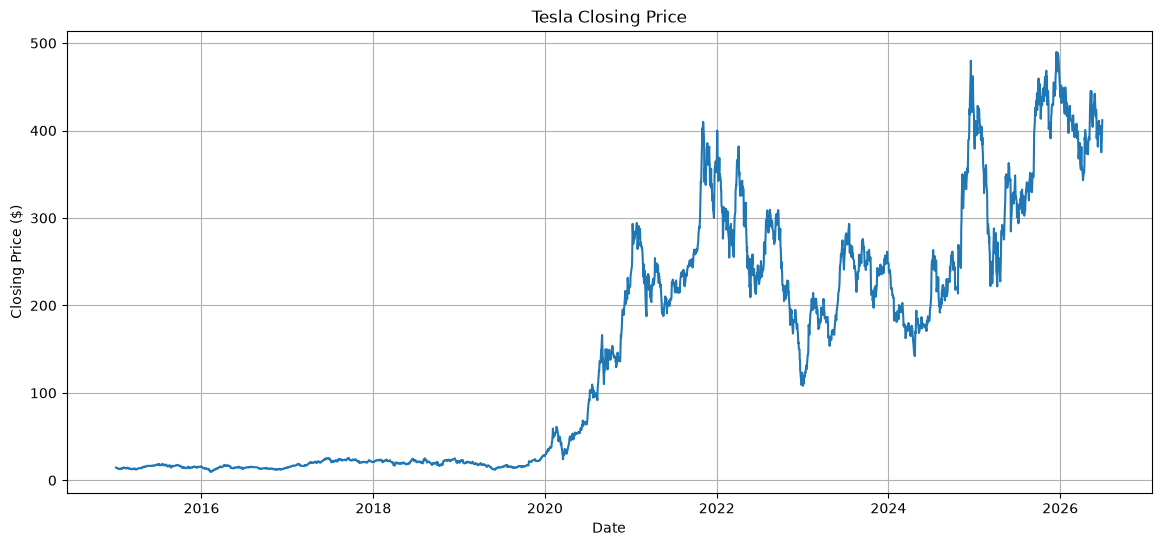

In [19]:
plt.figure(figsize=(14,6))

plt.plot(tsla_df.index, tsla_df["Close"])

plt.title("Tesla Closing Price")

plt.xlabel("Date")

plt.ylabel("Closing Price ($)")

plt.grid(True)

plt.show()

Daily Percentage Returns
how much the investment gained 

In [20]:
tsla_df["Daily_Return"] = tsla_df["Close"].pct_change()

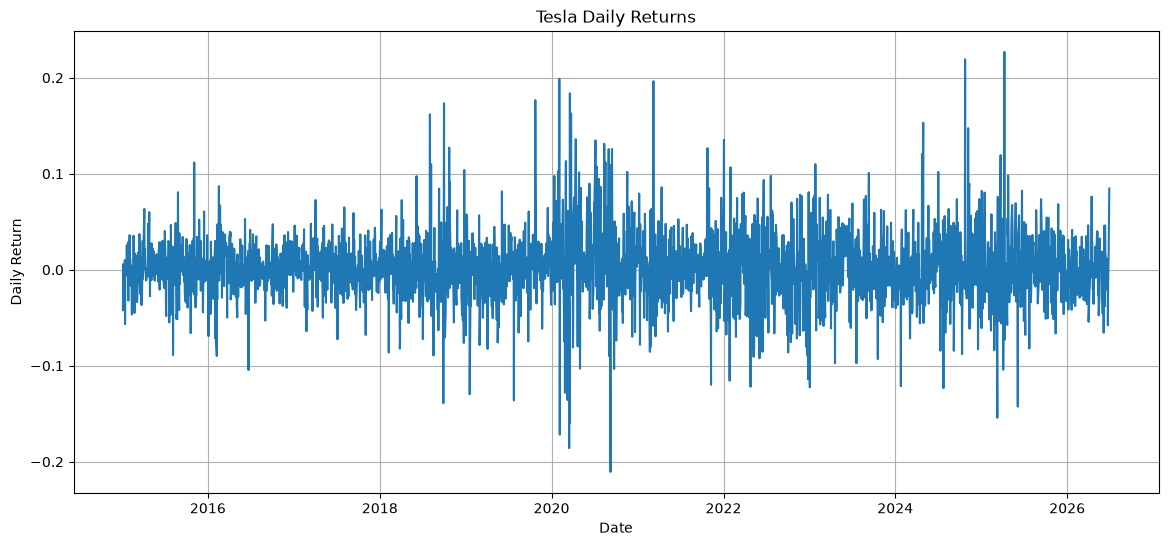

In [21]:
plt.figure(figsize=(14,6))

plt.plot(tsla_df.index,
         tsla_df["Daily_Return"])

plt.title("Tesla Daily Returns")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

In [22]:
window = 30

tsla_df["Rolling_Mean"] = (
    tsla_df["Close"]
    .rolling(window)
    .mean()
)

tsla_df["Rolling_STD"] = (
    tsla_df["Close"]
    .rolling(window)
    .std()
)

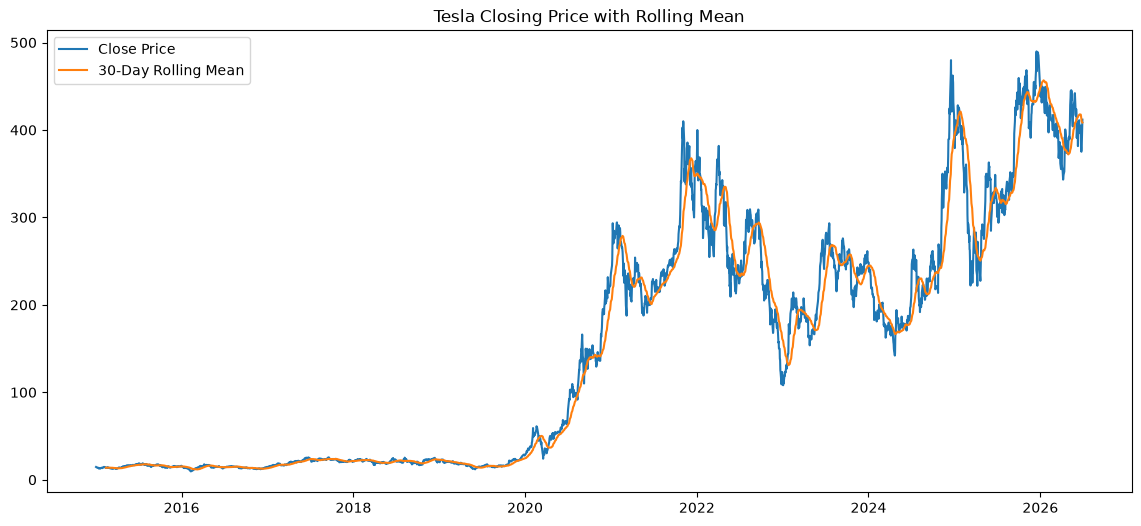

In [23]:
plt.figure(figsize=(14,6))

plt.plot(tsla_df["Close"],
         label="Close Price")

plt.plot(tsla_df["Rolling_Mean"],
         label="30-Day Rolling Mean")

plt.legend()

plt.title("Tesla Closing Price with Rolling Mean")

plt.show()

In [24]:
Q1 = tsla_df["Daily_Return"].quantile(0.25)
Q3 = tsla_df["Daily_Return"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = tsla_df[
    (tsla_df["Daily_Return"] < lower) |
    (tsla_df["Daily_Return"] > upper)
]

In [25]:
outliers.head()

Price,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,
Date,,,,,,,,
2015-08-06,16.408667,17.000000,15.741333,16.636000,219357000,-0.088846,17.719733,0.503382
2015-08-27,16.199333,16.316668,15.387333,15.400000,114840000,0.080724,16.837289,1.108552
2015-11-04,15.442000,15.516000,15.013333,15.133333,190896000,0.111735,15.113111,1.099353
2016-02-02,12.185333,12.874667,12.015333,12.828000,86604000,-0.071900,14.141956,1.129694
2016-02-05,10.840000,11.533333,10.516000,11.420000,141564000,-0.072606,13.738489,1.325180


In [26]:
outliers.sort_values("Daily_Return")

Price,Close,High,Low,Open,Volume,Daily_Return,Rolling_Mean,Rolling_STD
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,
Date,,,,,,,,
2020-09-08,110.070000,122.913330,109.959999,118.666664,346397100,-0.210628,120.199712,22.311102
2020-03-16,29.671333,32.991333,29.478001,31.299999,307342500,-0.185778,49.462089,7.317450
2020-02-05,48.980000,56.398666,46.940666,54.883999,726357000,-0.171758,35.649822,7.541756
2020-03-18,24.081333,26.990667,23.367332,25.933332,356793000,-0.160344,47.516222,9.126017
2025-03-10,222.149994,253.369995,220.000000,252.539993,189076900,-0.154262,336.557667,49.976421
...,...,...,...,...,...,...,...,...
2020-03-19,28.509333,30.133333,23.897333,24.980000,452932500,0.183877,46.833866,9.756329
2021-03-09,224.526672,226.029999,198.403336,202.726669,202569900,0.196412,255.348557,30.100871


C:\Users\mijuu\AppData\Local\Temp\ipykernel_7432\3588368851.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


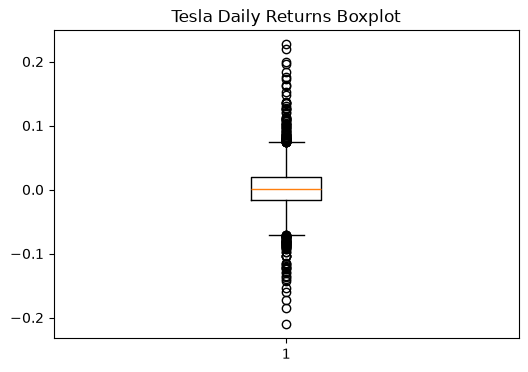

In [27]:
plt.figure(figsize=(6,4))

plt.boxplot(
    tsla_df["Daily_Return"].dropna(),
    vert=True
)

plt.title("Tesla Daily Returns Boxplot")

plt.show()

In [29]:
from statsmodels.tsa.stattools import adfuller

In [30]:
result = adfuller(
    tsla_df["Close"].dropna()
)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.0695991394177442
p-value: 0.7270419411549228


we fail to reject the null hypothesis. thus it is not stationary ( close price)

In [31]:
result_returns = adfuller(
    tsla_df["Daily_Return"].dropna()
)

print("ADF Statistic:", result_returns[0])
print("p-value:", result_returns[1])

ADF Statistic: -53.971892804251446
p-value: 0.0


daily return is stationary 

## Risk metrics

### VaR

In [32]:
returns = tsla_df["Daily_Return"].dropna()

In [33]:
VaR_95 = returns.quantile(0.05)

print(VaR_95)

-0.05166375515284559


The historical 95% Value at Risk (VaR) for Tesla is approximately -5.1%, meaning that on 95% of trading days the daily loss is expected to be less than 5.1%, while only about 5% of trading days experience larger losses.

### Sharpe Ratio

"How much return am I getting for every unit of risk I take?"

In [34]:
mean_return = returns.mean()

In [38]:
std_return = returns.std()

In [36]:
annual_return = mean_return * 252

In [39]:
annual_volatility = std_return * np.sqrt(252)

In [40]:
risk_free_rate = 0

In [41]:
sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(sharpe_ratio)

0.7944370048126023


For each unit of risk, the investment generated 0.79 units of return.